<h1 style="text-align: center;">Assessment 2: FIS 1</h1>
<h2 style="text-align: center;">Soft Computing</h2> 
<h3 style="text-align: center;">By Ruhan Shafi | u3284342</h3>

### `FIS1`: This `FIS` is designed to minimise the difference in average waiting times between cars on the main street and those on the side street

## Setup and Imports

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import trafficSimulator as trafficSimulator

## Inputs and Outputs
In this cell, the fuzzy inputs and outputs are being decleared, through the use of the `skfuzzy` functions, `ctrl.Antecedent(universe, label)` & `ctrl.Consequent(universe, label)` respectively. These inputs and outputs are used in Membership Function Defination and provides dictionary interfaces used in the construction of the `FIS`. 

In [2]:

# 'waiting' is cars on the side street waiting for the light to change.
waitingTraffic  = ctrl.Antecedent(np.arange(1, 100, 1), 'waiting')
# 'incoming' is cars on the main street waiting for the light to change.
incomingTraffic = ctrl.Antecedent(np.arange(0, 100, 1), 'incoming')

# 'wait duration' is main street green time
# 'open duration' is side street green time
waitingDuration = ctrl.Consequent(np.arange(0, 120, 1), 'wait duration')
openDuration    = ctrl.Consequent(np.arange(0, 120, 1), 'open duration')



## Membership Functions

Once the fuzzy inputs has been defined, the next step is to specifies membership functions. These describe fuzzy categories such as low, medium, and high. For example, the side street queue (`waitingTraffic`) and the main street input (`incomingTraffic`) has three categories:
* Low: defined as a triangle starting at 1, peaking at 1, and dropping to 0 at 25. This acts like a left shoulder, meaning that if the waiting cars are between 1 and 25, they are considered “low,” with the strongest membership at very small values.
* Medium: a triangle centered at 50 with sides at 15 and 85. This means a queue of around 50 is fully “medium,” while smaller or larger queues partly belong to this category.
* High: a triangle starting at 75, peaking at 99, and ending at 99. This acts like a right shoulder, so queues close to 100 cars are strongly “high.”

In [3]:

# Traffic MFs (Tuned to be less symmetric/more extreme to aid contrast)
waitingTraffic['low']    = fuzz.trimf(waitingTraffic.universe, [1, 1, 25])
waitingTraffic['medium'] = fuzz.trimf(waitingTraffic.universe, [15, 50, 85])
waitingTraffic['high']   = fuzz.trimf(waitingTraffic.universe, [75, 99, 99])

incomingTraffic['low']    = fuzz.trimf(incomingTraffic.universe, [0, 0, 25])
incomingTraffic['medium'] = fuzz.trimf(incomingTraffic.universe, [15, 50, 85])
incomingTraffic['high']   = fuzz.trimf(incomingTraffic.universe, [75, 99, 99])

# Output MFs 
waitingDuration['short'] = fuzz.trimf(waitingDuration.universe, [0, 10, 30])
waitingDuration['medium'] = fuzz.trimf(waitingDuration.universe, [20, 50, 70])
waitingDuration['long']  = fuzz.trimf(waitingDuration.universe, [60, 90, 120])
openDuration['short'] = fuzz.trimf(openDuration.universe, [0, 10, 30])
openDuration['medium'] = fuzz.trimf(openDuration.universe, [20, 50, 70])
openDuration['long']  = fuzz.trimf(openDuration.universe, [60, 90, 120])




## 3. Fuzzy Rules (Fairness Strategy: Using relative states to infer difference)

Objective: If one traffic level is high and the other is low, prioritize the high one.

The FIS has nine rules that capture how the traffic light should behave. These rules are grouped into three cases:

* Balanced traffic: If both streets have roughly the same traffic level (whether low, medium, or high), then the green times should be medium for both. This prevents bias and keeps the system fair.

* Side street dominant: If the side street is busier than the main street, the rules give the side street a longer green time. For example, if the side street is “high” and the main street is “low,” then the side gets a “long” green and the main gets a “short” one. This stops the side street from being starved.

* Main street dominant: If the main street is busier, the system does the reverse: it grants the main street more green time and shortens the side street’s green.

In [5]:

# Case 1: Balanced or Both Low/High
rule1 = ctrl.Rule(waitingTraffic['low'] & incomingTraffic['low'],
                  (waitingDuration['medium'], openDuration['medium'])) 
rule2 = ctrl.Rule(waitingTraffic['medium'] & incomingTraffic['medium'],
                  (waitingDuration['medium'], openDuration['medium'])) 
rule3 = ctrl.Rule(waitingTraffic['high'] & incomingTraffic['high'],
                  (waitingDuration['medium'], openDuration['medium'])) # Default balanced flow

# Case 2: Side Street (waiting) Dominant (Aggressively favor Side)
rule4 = ctrl.Rule(waitingTraffic['high'] & incomingTraffic['low'],
                  (waitingDuration['short'], openDuration['long']))
rule5 = ctrl.Rule(waitingTraffic['high'] & incomingTraffic['medium'],
                  (waitingDuration['medium'], openDuration['long'])) 
rule6 = ctrl.Rule(waitingTraffic['medium'] & incomingTraffic['low'],
                  (waitingDuration['short'], openDuration['long'])) 

# Case 3: Main Street (incoming) Dominant (Aggressively favor Main)
rule7 = ctrl.Rule(incomingTraffic['high'] & waitingTraffic['low'],
                  (waitingDuration['long'], openDuration['short']))
rule8 = ctrl.Rule(incomingTraffic['high'] & waitingTraffic['medium'],
                  (waitingDuration['long'], openDuration['medium'])) 
rule9 = ctrl.Rule(incomingTraffic['medium'] & waitingTraffic['low'],
                  (waitingDuration['long'], openDuration['short']))



## System Usage

Compiling the Model with the defined rules and making it ready for the Traffic Simulation

In [ ]:
fis_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
fis_simulator = ctrl.ControlSystemSimulation(fis_ctrl)

## Debug and Sanity Check
While this section of code has no real impact on the final performance on the `FIS` model, it was used in to development of the model to check if the distribution of priority between the main and side road. `FIS1` has equal priority while `FIS2` has greater priority placed on the Main Road.

In [7]:
fis_simulator.input['waiting'] = 45 
fis_simulator.input['incoming'] = 60 
fis_simulator.compute()
print("[DEBUG] Fairness FIS - : Wait (Main Duration):", fis_simulator.output['wait duration'],
      "Open (Side Duration):", fis_simulator.output['open duration'])



[DEBUG] Fairness FIS - : Wait (Main Duration): 46.45502645502648 Open (Side Duration): 46.45502645502648


## Simulation and Metrics


--- Compliant Fairness FIS Metrics ---
mean_wait_main: 226.63
mean_wait_side: 57.65
diff_wait: 168.98
max_wait_main: 442.30
max_wait_side: 123.98
throughput_main: 946.00
throughput_side: 110.00
total_throughput: 1056.00
fairness_index: 0.74
avg_queue_main: 339.68
avg_queue_side: 3.46
max_queue_main: 657.00
max_queue_side: 16.00


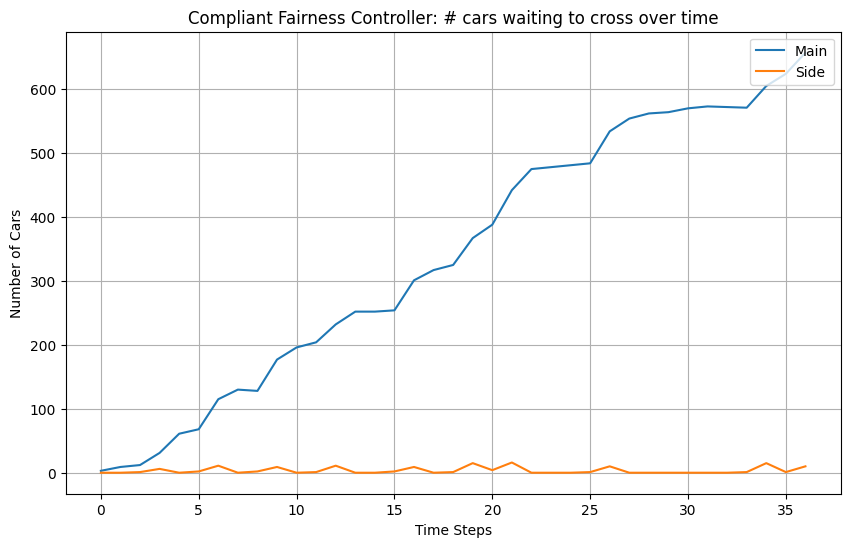

In [ ]:
# Run the traffic simulator with the defined FIS controller
num_cars_on_main, num_cars_on_side, wait_times_main, wait_times_side = trafficSimulator.simulate(fis_simulator, verbose = False)

# Differment metrics used for eval and their calculation code + formatting/plotting 
def evaluate_metrics(num_cars_on_main, num_cars_on_side, wait_times_main, wait_times_side):
    metrics = {}
    metrics['mean_wait_main'] = np.mean(wait_times_main) if len(wait_times_main) > 0 else 0
    metrics['mean_wait_side'] = np.mean(wait_times_side) if len(wait_times_side) > 0 else 0
    metrics['diff_wait']      = abs(metrics['mean_wait_main'] - metrics['mean_wait_side'])
    metrics['max_wait_main']  = np.max(wait_times_main) if len(wait_times_main) > 0 else 0
    metrics['max_wait_side']  = np.max(wait_times_side) if len(wait_times_side) > 0 else 0
    metrics['throughput_main'] = len(wait_times_main)
    metrics['throughput_side'] = len(wait_times_side)
    metrics['total_throughput'] = metrics['throughput_main'] + metrics['throughput_side']
    
    waits = np.array([metrics['mean_wait_main'], metrics['mean_wait_side']])
    metrics['fairness_index'] = (np.sum(waits)**2) / (len(waits) * np.sum(waits**2)) if np.sum(waits) > 0 else 1
    
    metrics['avg_queue_main'] = np.mean(num_cars_on_main)
    metrics['avg_queue_side'] = np.mean(num_cars_on_side)
    metrics['max_queue_main'] = np.max(num_cars_on_main)
    metrics['max_queue_side'] = np.max(num_cars_on_side)
    return metrics

metrics = evaluate_metrics(num_cars_on_main, num_cars_on_side, wait_times_main, wait_times_side)
print("\n--- Compliant Fairness FIS Metrics ---")
for k, v in metrics.items():
    print(f"{k}: {v:.2f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(num_cars_on_main)
plt.plot(num_cars_on_side)
plt.legend(["Main", "Side"], loc="upper right")
plt.title("Compliant Fairness Controller: # cars waiting to cross over time")
plt.xlabel("Time Steps")
plt.ylabel("Number of Cars")
plt.grid(True)
plt.show()

# Report

```--- Compliant Fairness FIS1 Metrics ---
mean_wait_main: 226.63
mean_wait_side: 57.65
diff_wait: 168.98
max_wait_main: 442.30
max_wait_side: 123.98
throughput_main: 946.00
throughput_side: 110.00
total_throughput: 1056.00
fairness_index: 0.74
avg_queue_main: 339.68
avg_queue_side: 3.46
max_queue_main: 657.00
max_queue_side: 16.00

--- Compliant Main Priority FIS2 Metrics ---
mean_wait_main: 230.75
mean_wait_side: 51.86
diff_wait: 178.89
max_wait_main: 449.14
max_wait_side: 100.86
throughput_main: 941.00
throughput_side: 102.00
total_throughput: 1043.00
fairness_index: 0.71
avg_queue_main: 370.31
avg_queue_side: 2.62
max_queue_main: 674.00
max_queue_side: 15.00

The different metrics for FIS1 show that, unfortunately, the main goal of having an equal distribution of wait time for both the main and side streets was not achieved, and this is reflected in the `diff_wait` being 168, indicating a substantial disparity in service quality between the two streets. Additionally, the `mean_wait_main` value of 226.63 is very high, suggesting that the FIS system prioritised flow too little or too late, causing the primary congestion point, which might be a contributing factor to the poor `diff_wait` value. The fairness value of this system is 0.74, which suggests that there is room for improvement for this model.

On a more positive note, the `total_throughput` value of 1056 means that this system is overall efficient at moving cars, even if it didn't align with the requirements of this particular FIS.
